# 03 — Preprocessing Pipelines
Applies the five pipelines under the leakage-safe rule (fit on training fold only) and documents the final feature set and the log1p+Ratio (18) vs Full Manual (17) difference.

In [1]:
import json, inspect, warnings, os, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (StandardScaler, RobustScaler, PowerTransformer, MinMaxScaler, QuantileTransformer)
from sklearn.metrics import (accuracy_score, matthews_corrcoef, roc_auc_score, recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from scipy import stats
from lightgbm import LGBMClassifier
os.makedirs("results", exist_ok=True)
RS = 42
TEAL,ROSE,ORANGE,SAND,RED,LAV,SLATE,INK = ('#4A90A4','#C4887D','#E67E22','#C4A882','#C0392B','#8E7CC3','#7A8B9A','#2C3E4F')
plt.rcParams.update({'font.family':'DejaVu Sans','axes.facecolor':'#FAFBFC','figure.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.color':'#E4E9F0',
    'axes.titleweight':'bold','axes.axisbelow':True,'savefig.dpi':200,'savefig.bbox':'tight'})
NAMES = ['Manual Expert','DeepSeek','Claude Sonnet 4.6','GPT-5.4','CAAFE']
SHORT = ['Manual','DeepSeek','Claude 4.6','GPT-5.4','CAAFE']
COLS  = [TEAL,ROSE,RED,ORANGE,LAV]
CONT  = ['AGE','ANNUALCONTRIBUTION','ANNUALCLAIMAMOUNT','UNITSTOTAL']
DATA  = "Final Prepared Dataset - Diabetes and Hypertension Data.xlsx"

def load_raw():
    df = pd.read_excel(DATA)
    n_raw = len(df); df = df.drop_duplicates().reset_index(drop=True); n_dup = n_raw - len(df)
    df["ADHERENCE"] = (df["ADHERENCE"]=="ADHERENT").astype(int)
    for c in df.columns:
        if df[c].dtype=="bool": df[c]=df[c].astype(int)
    return df, n_raw, n_dup

def load_and_split():
    df,_,_ = load_raw()
    y=df["ADHERENCE"]; X=df.drop(columns=["ADHERENCE"])
    return train_test_split(X,y,test_size=0.2,stratify=y,random_state=RS)

def _manual(Xp):
    Xp=Xp.copy()
    Xp["LOG_CLAIM"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]); Xp["LOG_UNITS"]=np.log1p(Xp["UNITSTOTAL"])
    Xp["LOG_CONTRIB"]=np.log1p(Xp["ANNUALCONTRIBUTION"])
    Xp["CLAIM_PER_UNIT"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["UNITSTOTAL"]+1))
    Xp["CLAIM_RATIO"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["ANNUALCONTRIBUTION"]+1))
    Xp["UNITS_PER_AGE"]=Xp["UNITSTOTAL"]/(Xp["AGE"]+1); return Xp

_NS={"np":np,"pd":pd,"StandardScaler":StandardScaler,"RobustScaler":RobustScaler,
     "PowerTransformer":PowerTransformer,"MinMaxScaler":MinMaxScaler,"QuantileTransformer":QuantileTransformer}
def _load(p):
    ns=dict(_NS); exec(open(p,encoding="utf-8").read(),ns); return ns["preprocess"]
FROZEN={"DeepSeek":_load("llm_raw/DeepSeek_preprocess.py"),
        "Claude Sonnet 4.6":_load("llm_raw/Claude_Sonnet_4.6_preprocess.py"),
        "GPT-5.4":_load("llm_raw/GPT-5.4_preprocess.py")}
def _caafe(frame):
    ns={"df":frame.copy(),"np":np,"pd":pd}; exec(open("llm_raw/CAAFE_code.py",encoding="utf-8").read(),ns)
    return ns["df"].select_dtypes(include=[np.number]).fillna(0)
def transform_pair(name,x_fit,x_eval):
    if name=="Manual Expert": return _manual(x_fit),_manual(x_eval)
    if name=="CAAFE":
        tr=_caafe(x_fit); te=_caafe(x_eval).reindex(columns=tr.columns,fill_value=0); return tr,te
    tr,te=FROZEN[name](x_fit.copy(),x_eval.copy())
    if not isinstance(tr,pd.DataFrame):
        cols=(list(x_fit.columns)+["CONTRIBUTION_CLAIM_RATIO","UNITS_PER_CLAIM"]) if (name=="DeepSeek" and tr.shape[1]==x_fit.shape[1]+2) else [f"f{i}" for i in range(tr.shape[1])]
        tr=pd.DataFrame(tr,index=x_fit.index,columns=cols)
    if not isinstance(te,pd.DataFrame): te=pd.DataFrame(te,index=x_eval.index,columns=tr.columns)
    return tr,te.reindex(columns=tr.columns,fill_value=0)
def san(df): return pd.DataFrame(df).replace([np.inf,-np.inf],np.nan).fillna(0.0)
def nb_se(d,k=10):
    d=np.asarray(d); n=d.size; return np.sqrt(d.var(ddof=1)*(1.0/n+(1.0/k)/(1-1.0/k)))
def tost90(d,k=10):
    d=np.asarray(d); m=d.mean(); se=nb_se(d,k); c=stats.t.ppf(0.95,d.size-1); return m,se,[m-c*se,m+c*se]
def cv_metrics(name,X,y,drop_units=False,k=10,repeats=1):
    accs,mccs,aucs=[],[],[]
    for r in range(repeats):
        for tr,va in StratifiedKFold(k,shuffle=True,random_state=(RS if repeats==1 else 2026+r)).split(X,y):
            ftr,fva=transform_pair(name,X.iloc[tr],X.iloc[va])
            if drop_units:
                uc=[c for c in ftr.columns if 'UNIT' in c.upper()]
                ftr=ftr.drop(columns=uc); fva=fva.drop(columns=[c for c in uc if c in fva.columns])
            ftr,fva=san(ftr),san(fva)
            m=LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1).fit(ftr,y.iloc[tr])
            p=m.predict(fva); pr=m.predict_proba(fva)[:,1]
            accs.append(accuracy_score(y.iloc[va],p)); mccs.append(matthews_corrcoef(y.iloc[va],p)); aucs.append(roc_auc_score(y.iloc[va],pr))
    return np.array(accs),np.array(mccs),np.array(aucs)
x_tr,x_ho,y_tr,y_ho = load_and_split()
print("Setup complete |", f"{len(x_tr)+len(x_ho):,} records, {x_tr.shape[1]} predictors")

Setup complete | 24,071 records, 11 predictors


### Final feature counts and sample transformed output

In [2]:
rows=[]
for n in NAMES:
    tr,_=transform_pair(n,x_tr,x_ho); rows.append([n,tr.shape[1]])
feat=pd.DataFrame(rows,columns=['Pipeline','Final #features'])
feat['Source']=['Human (predefined)','One-shot LLM','One-shot LLM','One-shot LLM','Iterative LLM']
display(feat)
tr,_=transform_pair('Manual Expert',x_tr,x_ho)
print('Manual Expert engineered columns:'); print(list(tr.columns))
display(tr.head(3))

,Pipeline,Final #features,Source
0,Manual Expert,17,Human (predefined)
1,DeepSeek,13,One-shot LLM
2,Claude Sonnet 4.6,22,One-shot LLM
3,GPT-5.4,34,One-shot LLM
4,CAAFE,12,Iterative LLM


Manual Expert engineered columns:
['AGE', 'ANNUALCONTRIBUTION', 'ANNUALCLAIMAMOUNT', 'UNITSTOTAL', 'GENDER_M', 'SCHEMETYPE_MEDIUM', 'SCHEMETYPE_PREMIUM', 'DIAGNOSIS_HYPERTENSION', 'COVERTYPE_STANDARD', 'COMORBIDITY_NO_COMORBIDITY', 'COMPLICATIONDEVELOPMENT_NO_COMPLICATION', 'LOG_CLAIM', 'LOG_UNITS', 'LOG_CONTRIB', 'CLAIM_PER_UNIT', 'CLAIM_RATIO', 'UNITS_PER_AGE']


,AGE,ANNUALCONTRIBUTION,ANNUALCLAIMAMOUNT,UNITSTOTAL,GENDER_M,SCHEMETYPE_MEDIUM,SCHEMETYPE_PREMIUM,DIAGNOSIS_HYPERTENSION,COVERTYPE_STANDARD,COMORBIDITY_NO_COMORBIDITY,COMPLICATIONDEVELOPMENT_NO_COMPLICATION,LOG_CLAIM,LOG_UNITS,LOG_CONTRIB,CLAIM_PER_UNIT,CLAIM_RATIO,UNITS_PER_AGE
21253,51,808284.0,3695.45,30.0,0,0,0,1,1,1,1,8.215128,3.433987,13.602670,4.789224,0.004562,0.576923
20183,34,6889900.0,900.00,14.0,1,0,1,1,1,1,1,6.803505,2.708050,15.745567,4.110874,0.000131,0.400000
14004,55,2718696.0,93640.68,196.0,1,1,0,1,1,1,1,11.447231,5.283204,14.815663,6.166118,0.033863,3.500000


### Feature-count demonstration: log1p+Ratio (18) vs Full Manual (17)

log1p+Ratio variant: 18 features (keeps intermediate CLAIM_PER_UNIT_raw)
Full Manual Expert : 17 features (drops the redundant intermediate)


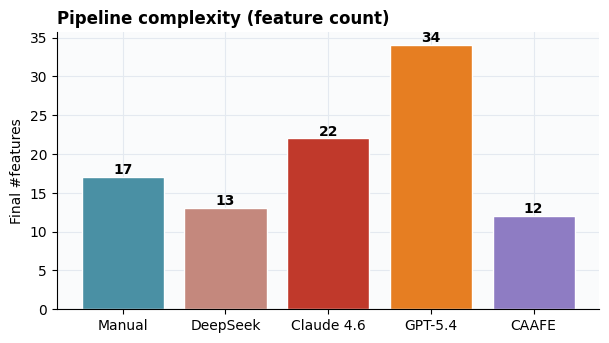

In [3]:
def eng(X, log=False, ratio=False):
    Xp=X.copy()
    if log:
        for c in ['ANNUALCLAIMAMOUNT','UNITSTOTAL','ANNUALCONTRIBUTION']: Xp['LOG_'+c]=np.log1p(Xp[c])
    if ratio:
        Xp['CLAIM_PER_UNIT_raw']=Xp['ANNUALCLAIMAMOUNT']/(Xp['UNITSTOTAL']+1)   # intermediate kept in ablation
        Xp['CLAIM_PER_UNIT']=np.log1p(Xp['CLAIM_PER_UNIT_raw'])
        Xp['CLAIM_RATIO']=np.log1p(Xp['ANNUALCLAIMAMOUNT']/(Xp['ANNUALCONTRIBUTION']+1))
        Xp['UNITS_PER_AGE']=Xp['UNITSTOTAL']/(Xp['AGE']+1)
    return Xp
n_ablation=eng(x_tr,log=True,ratio=True).shape[1]
n_manual=_manual(x_tr).shape[1]
print(f'log1p+Ratio variant: {n_ablation} features (keeps intermediate CLAIM_PER_UNIT_raw)')
print(f'Full Manual Expert : {n_manual} features (drops the redundant intermediate)')
feat.to_excel('results/03_pipeline_features.xlsx',index=False)
fig,ax=plt.subplots(figsize=(7,3.6)); ax.bar(SHORT,feat['Final #features'],color=COLS,edgecolor='white')
for i,v in enumerate(feat['Final #features']): ax.text(i,v+0.4,str(v),ha='center',fontweight='bold')
ax.set_ylabel('Final #features'); ax.set_title('Pipeline complexity (feature count)',loc='left')
plt.savefig('results/03_feature_counts.png'); plt.show()